In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/fedfunds_features.csv"
)

rates = df["FEDFUNDS"].values

In [2]:
r_t = rates[:-1]

r_next = rates[1:]

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
model = LinearRegression()

model.fit(
    r_t.reshape(-1,1),
    r_next
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.99]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.04724
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[103.1]


In [7]:
import pandas as pd
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current folder:
c:\Users\sonow\Downloads\stochastic-interest-rate-model\notebooks

Files here:
['01_data_cleaning.ipynb', '02_eda.ipynb', '02_exploratory_data_analysis.ipynb', '03_feature_engineering.ipynb', '03_vasicek_model.ipynb', '04_cir_model.ipynb', '05_parameter_estimation.ipynb', '05_prediction.ipynb']


In [8]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

In [9]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

..\data\processed\fedfunds_features.csv
..\data\processed\vasicek_simulations.csv
..\data\raw\FEDFUNDS.csv
..\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\data_x_x2_x3.csv
..\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\msft.csv
..\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\Stocks.csv
..\venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
..\venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
..\venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-1.csv
..\venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-2.csv
..\venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-1.csv
..\venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-2.csv
..\venv\Lib\site-packages\numpy\random\tests\data\philox-testset-1.csv
..\venv\Lib\site-packages\numpy\random\tests\data\philox-testset-2.csv
..\venv\Lib\site-packages\numpy\random\tests\data\sfc64-testset-1.csv
..\venv\Lib\site-packages\numpy\random

In [10]:
import pandas as pd

df = pd.read_csv("../data/raw/FEDFUNDS.csv")

print(df.head())

  observation_date  FEDFUNDS
0       1954-07-01      0.80
1       1954-08-01      1.22
2       1954-09-01      1.07
3       1954-10-01      0.85
4       1954-11-01      0.83


In [11]:
df = pd.read_csv("../data/processed/fedfunds_features.csv")

print(df.head())
print(df.columns)

  observation_date  FEDFUNDS  lag_1  lag_2  lag_3  rolling_mean_3  \
0       1955-06-01      1.64   1.43   1.43   1.35        1.500000   
1       1955-07-01      1.68   1.64   1.43   1.43        1.583333   
2       1955-08-01      1.96   1.68   1.64   1.43        1.760000   
3       1955-09-01      2.18   1.96   1.68   1.64        1.940000   
4       1955-10-01      2.24   2.18   1.96   1.68        2.126667   

   rolling_mean_12  rate_change  pct_change  volatility_12  trend  year  \
0         1.215000         0.21    0.146853       0.270773      1  1955   
1         1.288333         0.04    0.024390       0.267304      1  1955   
2         1.350000         0.28    0.166667       0.328468      1  1955   
3         1.442500         0.22    0.112245       0.392501      1  1955   
4         1.558333         0.06    0.027523       0.406601      1  1955   

   month  quarter  
0      6        2  
1      7        3  
2      8        3  
3      9        3  
4     10        4  
Index(['observ

In [12]:
from sklearn.linear_model import LinearRegression

X = df[['lag_1']]
y = df['FEDFUNDS']

model = LinearRegression()
model.fit(X, y)

print("Slope (beta):", model.coef_[0])
print("Intercept (alpha):", model.intercept_)

Slope (beta): 0.990276591767867
Intercept (alpha): 0.04769683370484401


In [13]:
beta = model.coef_[0]
alpha = model.intercept_

print("Alpha =", alpha)
print("Beta =", beta)

Alpha = 0.04769683370484401
Beta = 0.990276591767867


In [14]:
import numpy as np

dt = 1/12  # monthly data

kappa = -np.log(beta) / dt
theta = alpha / (1 - beta)

print("Kappa =", kappa)
print("Theta =", theta)

Kappa = 0.11725187100346939
Theta = 4.905361635153804


In [15]:
beta = model.coef_[0]

In [16]:
alpha = model.intercept_

In [17]:
print(beta)
print(alpha)

0.990276591767867
0.04769683370484401


In [18]:
dt = 1/12

In [20]:
print(df.columns)

Index(['observation_date', 'FEDFUNDS', 'lag_1', 'lag_2', 'lag_3',
       'rolling_mean_3', 'rolling_mean_12', 'rate_change', 'pct_change',
       'volatility_12', 'trend', 'year', 'month', 'quarter'],
      dtype='str')


In [21]:
r_t = df['lag_1'].values
r_next = df['FEDFUNDS'].values

In [22]:
sigma = np.std(
    r_next -
    model.predict(
        r_t.reshape(-1,1)
    )
)

print("Sigma =", sigma)

Sigma = 0.48039199725433296


c:\Users\sonow\Downloads\stochastic-interest-rate-model\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
print("Alpha =", alpha)
print("Beta =", beta)

Alpha = 0.04769683370484401
Beta = 0.990276591767867


In [24]:
X = df[['lag_1']]
y = df['FEDFUNDS']

residuals = y - model.predict(X)

sigma = np.std(residuals)

print("Sigma =", sigma)

Sigma = 0.48039199725433296


In [25]:
dt = 1/12

kappa = -np.log(beta) / dt
theta = alpha / (1 - beta)

print("Kappa =", kappa)
print("Theta =", theta)
print("Sigma =", sigma)

Kappa = 0.11725187100346939
Theta = 4.905361635153804
Sigma = 0.48039199725433296


In [26]:
r_t = df['lag_1'].values
r_next = df['FEDFUNDS'].values

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
# Estimated parameters
kappa = 0.11725187100346939
theta = 4.905361635153804
sigma = 0.48039199725433296

dt = 1/12
n_steps = 120      # 10 years
n_sims = 100

r0 = 4.5

In [29]:
a = (1 - beta) / dt

b = alpha / (1 - beta)

sigma = np.std(
    r_next -
    model.predict(
        r_t.reshape(-1,1)
    )
)

c:\Users\sonow\Downloads\stochastic-interest-rate-model\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [30]:
print("a =", a)
print("b =", b)
print("sigma =", sigma)

a = 0.11668089878559629
b = 4.905361635153804
sigma = 0.48039199725433296


In [31]:
def cir_simulation(
    r0,
    a,
    b,
    sigma,
    T,
    dt
):

    n_steps = int(T/dt)

    rates = np.zeros(n_steps)

    rates[0] = r0

    for t in range(1,n_steps):

        shock = np.random.normal()

        dr = (
            a*(b-rates[t-1])*dt
            +
            sigma*np.sqrt(
                max(rates[t-1],0)
            )*np.sqrt(dt)*shock
        )

        rates[t] = max(
            rates[t-1]+dr,
            0
        )

    return rates

In [33]:
rates = df['FEDFUNDS'].values

print(rates[:5])
print(rates[-1])

[1.64 1.68 1.96 2.18 2.24]
3.63


In [34]:
r0 = rates[-1]

In [35]:
print(cir_simulation)

<function cir_simulation at 0x000001E22D694EA0>


In [36]:
rates = df['FEDFUNDS'].values

r0 = rates[-1]

print("Last interest rate =", r0)

Last interest rate = 3.63


In [37]:
def cir_simulation(
    r0,
    a,
    b,
    sigma,
    T,
    dt
):

    n_steps = int(T/dt)

    rates = np.zeros(n_steps)

    rates[0] = r0

    for t in range(1,n_steps):

        shock = np.random.normal()

        dr = (
            a*(b-rates[t-1])*dt
            +
            sigma*np.sqrt(
                max(rates[t-1],0)
            )*np.sqrt(dt)*shock
        )

        rates[t] = max(
            rates[t-1]+dr,
            0
        )

    return rates

In [38]:
r0 = rates[-1]

cir_path = cir_simulation(
    r0,
    a,
    b,
    sigma,
    T=5,
    dt=1/12
)

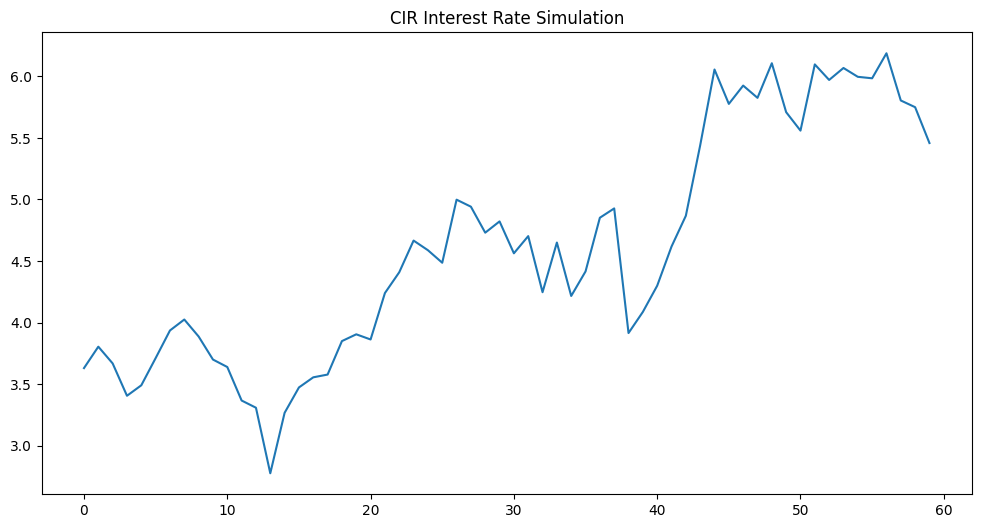

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(cir_path)

plt.title(
    "CIR Interest Rate Simulation"
)

plt.show()

In [42]:
import numpy as np

def vasicek_simulation(r0, a, b, sigma, T=5, dt=1/12):
    n_steps = int(T / dt)

    rates = np.zeros(n_steps)
    rates[0] = r0

    for t in range(1, n_steps):
        dr = a * (b - rates[t-1]) * dt + sigma * np.sqrt(dt) * np.random.normal()
        rates[t] = rates[t-1] + dr

    return rates

In [43]:
a = kappa
b = theta

rates = df['FEDFUNDS'].values
r0 = rates[-1]

vasicek_path = vasicek_simulation(
    r0,
    a,
    b,
    sigma,
    T=5,
    dt=1/12
)

print(vasicek_path[:10])

[3.63       3.37066728 3.54657493 3.65179774 3.79881351 3.8180907
 3.77643928 3.85267331 3.88614842 3.94485068]


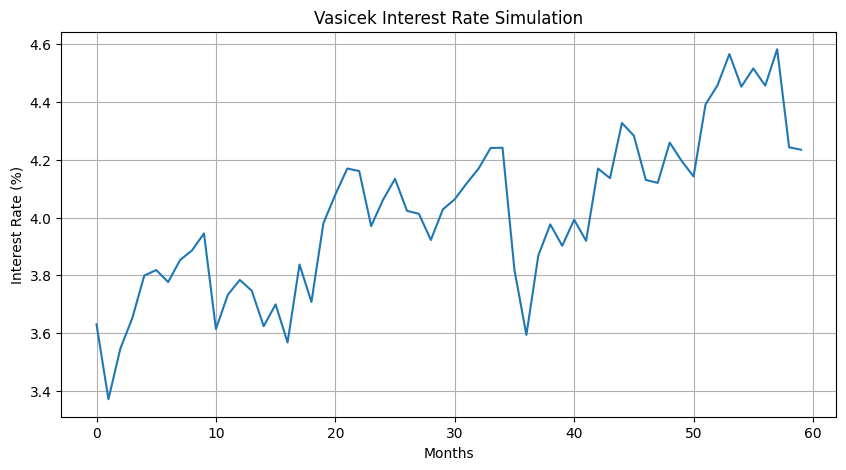

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(vasicek_path)

plt.title("Vasicek Interest Rate Simulation")
plt.xlabel("Months")
plt.ylabel("Interest Rate (%)")

plt.grid(True)
plt.show()

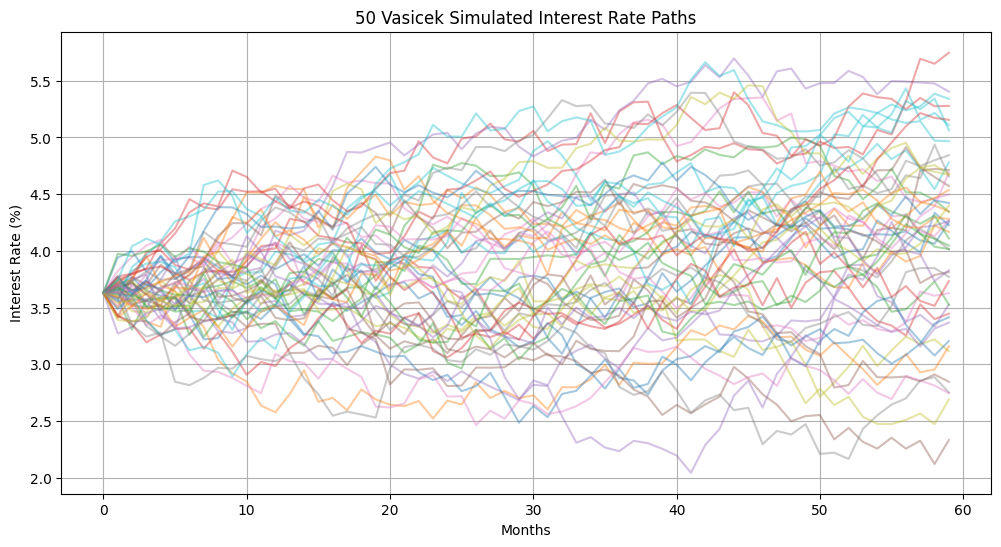

In [45]:
plt.figure(figsize=(12,6))

for _ in range(50):
    path = vasicek_simulation(
        r0,
        a,
        b,
        sigma,
        T=5,
        dt=1/12
    )

    plt.plot(path, alpha=0.4)

plt.title("50 Vasicek Simulated Interest Rate Paths")
plt.xlabel("Months")
plt.ylabel("Interest Rate (%)")
plt.grid(True)

plt.show()

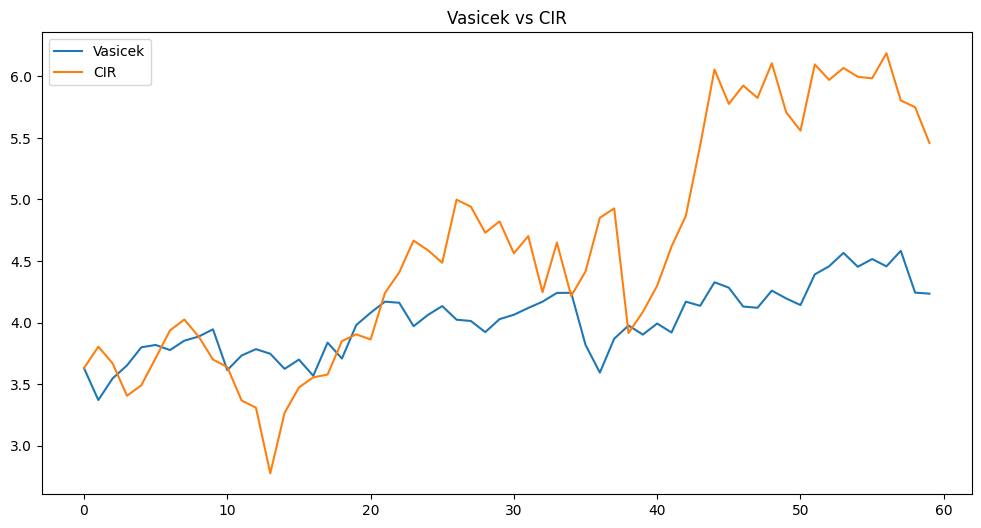

In [47]:
plt.figure(figsize=(12,6))

plt.plot(
    vasicek_path,
    label="Vasicek"
)

plt.plot(
    cir_path,
    label="CIR"
)

plt.legend()

plt.title(
    "Vasicek vs CIR"
)

plt.show()

In [48]:
print(a)
print(b)
print(sigma)

0.11725187100346939
4.905361635153804
0.48039199725433296


In [49]:
df.columns

Index(['observation_date', 'FEDFUNDS', 'lag_1', 'lag_2', 'lag_3',
       'rolling_mean_3', 'rolling_mean_12', 'rate_change', 'pct_change',
       'volatility_12', 'trend', 'year', 'month', 'quarter'],
      dtype='str')